## Figure 9: Time averaged current shape profile, current head and body height

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# Use given style and color maps
from colors import mixing_c_map
from colors import type_marker_map

plt.style.use("james2026lock.mplstyle")

# constants
rho_part = 2600
d_part = 22e-6
rho_water = 998.2
visc = 1e-3
h0 = 0.25
l0 = 0.27

# load experiment table
metadata = pd.read_csv("data/metadata.csv")
folder = "/Users/cara/Library/CloudStorage/OneDrive-UBC/PhD/Experiments/2025/Experiment_files/datafiles"

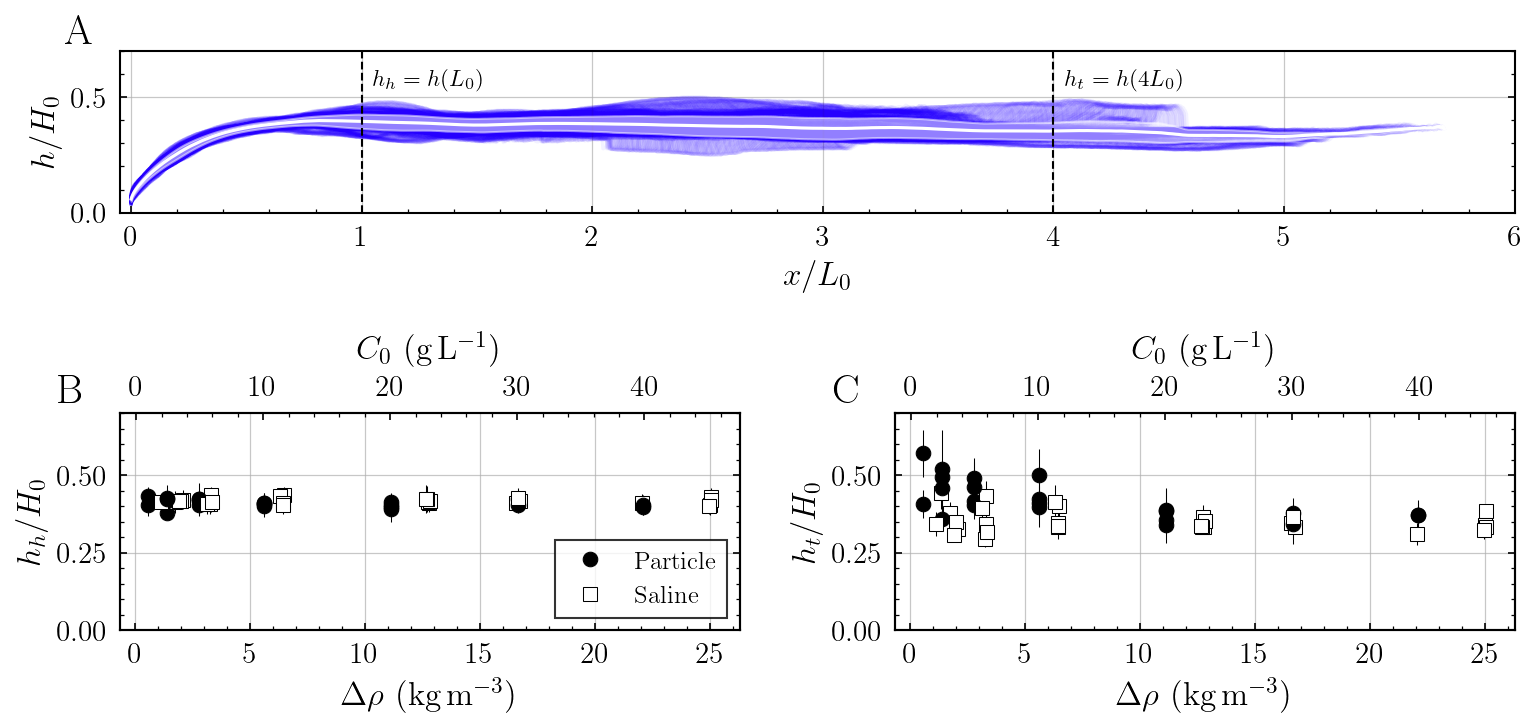

In [11]:
fig = plt.figure(figsize=(12, 9))
gs = gridspec.GridSpec(
    2, 2, figure=fig, height_ratios=[3, 0.6], hspace=-0.4, wspace=0.25
)

ax_top = fig.add_subplot(gs[0, :])  # spans both columns
ax_bot_left = fig.add_subplot(gs[1, 0])
ax_bot_right = fig.add_subplot(gs[1, 1])

# --- Panel A/B: h at L0 and 4L0 vs delta_rho ---
ax1 = ax_bot_left.twiny()
ax2 = ax_bot_right.twiny()

hh_s, hh_p, ht_s, ht_p, ht_plt10 = [], [], [], [], []

for _, row in metadata.iterrows():
    filename = folder + "/" + row.file_name + ".npy"
    data = np.load(filename, allow_pickle=True).item()

    avg_height = np.abs(data["av_shape"]) / h0
    std_profile = np.abs(data["av_shape_std"]) / h0
    xcenters = np.abs(data["xcenters"]) / l0

    idx_l0 = np.argmin(np.abs(xcenters - 1))
    h_l0 = avg_height[idx_l0]
    h_std_l0 = std_profile[idx_l0]

    idx_4l0 = np.argmin(np.abs(xcenters - 4))
    h_4l0 = avg_height[idx_4l0]
    h_std_4l0 = std_profile[idx_4l0]

    c = "white" if row.type == "saline" else "black"
    errorbar_kwargs = dict(
        markerfacecolor=c,
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
        color=c,
        ecolor="k",
        elinewidth=0.5,
        marker=type_marker_map.get(row["type"]),
    )

    ax_bot_left.errorbar(row.del_rho, h_l0, yerr=h_std_l0, **errorbar_kwargs)
    ax_bot_right.errorbar(row.del_rho, h_4l0, yerr=h_std_4l0, **errorbar_kwargs)

    if row["type"] == "part":
        for twax in [ax1, ax2]:
            twax.scatter(row.C0, h_l0, c="r", alpha=0)
            twax.set_xlim(-1.3, 47.5)
            twax.grid(False)
            twax.set_xlabel("$C_0$ (g\\,L$^{-1}$)", labelpad=8)
        ht_p.append(h_4l0)
        hh_p.append(h_l0)
        if row.C0 > 10:
            ht_plt10.append(h_4l0)
    else:
        ht_s.append(h_4l0)
        hh_s.append(h_l0)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Particle",
        markerfacecolor="black",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="Saline",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
]
ax_bot_left.legend(handles=legend_elements, loc="lower right")

for axis in [ax_bot_left, ax_bot_right]:
    axis.set_xlabel("$\\Delta \\rho$ (kg\\,m$^{-3}$)")
    axis.set_ylim([0, 0.7])

ax_bot_left.set_ylabel("$h_{h}/H_0$")
ax_bot_right.set_ylabel("$h_{t}/H_0$")

# --- Panel C: front profile for selected experiment ---
select_exp = metadata[metadata["exp_code"] == "JH5"].iloc[0]
filename = folder + "/" + select_exp.file_name + ".npy"
data = np.load(filename, allow_pickle=True).item()

height_stack = np.abs(data["height_stack"])
mean_profile = np.abs(data["av_shape"])
std_profile = np.abs(data["av_shape_std"])
x = np.abs(data["xcenters"])

c = mixing_c_map.get(select_exp["mixing"])
ax_top.plot(x / l0, height_stack.T / h0, c=c, alpha=0.05)
ax_top.fill_between(
    x / l0,
    (mean_profile - std_profile) / h0,
    (mean_profile + std_profile) / h0,
    color="w",
    alpha=0.5,
    zorder=2,
)
ax_top.plot(x / l0, mean_profile / h0, c="w", linewidth=1.5, zorder=3)
ax_top.vlines([1, 4], 0, 0.7, colors="k", linestyles="--", linewidth=1, zorder=5)
ax_top.set_xlabel("$x/L_0$ ")
ax_top.set_ylabel("$h/H_0$ ")
ax_top.set_ylim([0, 0.7])
ax_top.set_xlim([-0.05, 6])
ax_top.set_aspect("equal")

# --- Panel labels ---
offsets = [(-0.04, 1.05), (-0.1, 1.05), (-0.1, 1.05)]
for axis, label, (ox, oy) in zip(
    [ax_top, ax_bot_left, ax_bot_right], ["A", "B", "C"], offsets
):
    axis.annotate(
        label,
        xy=(ox, oy),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )

ax_top.text(
    1.05,
    0.55,
    "$h_h = h(L_0)$",
    fontsize=11,
)

ax_top.text(
    4.05,
    0.55,
    "$h_t = h(4L_0)$",
    fontsize=11,
)

plt.savefig("figures/figure_9.png", dpi=300, bbox_inches="tight")
plt.show()